In [1]:
# 1. Standard Library Imports
import calendar
import json
import os
import pickle
import sys
import warnings
from datetime import datetime,timedelta
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple


# 2. Resolve local path dynamically BEFORE local imports
current_dir = Path.cwd()
for base in [current_dir, current_dir.parent, current_dir.parent.parent]:
    if (base / "utils").exists() and str(base) not in sys.path:
        sys.path.insert(0, str(base))
        break

# 3. Third-Party Imports
import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import xgboost as xgb
from typing import Union
from catboost import CatBoostRegressor
from dotenv import load_dotenv
from eventregistry import * # Note: Wildcard imports (*) are generally discouraged
from IPython.display import Markdown, SVG, display
from openai import OpenAI
from pyvis.network import Network
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from ta.momentum import ROCIndicator, RSIIndicator
from ta.trend import MACD, SMAIndicator
from ta.volatility import BollingerBands
from torch.utils.data import DataLoader, Dataset, TensorDataset

# 4. Local Application Imports
from utils.internal_methods import (
    build_unified_graph,
    visualize_events_in_time_window,
    visualize_events_in_time_window_dynamic,    
    visualize_important_features,
    visualize_knowledge_graph,
    visualize_unified_graph,
    generate_explanation,
)


# ─────────────────────────────────────────────────────────────────────────────
# ── Configuration & Display Settings
# ─────────────────────────────────────────────────────────────────────────────

# Ignore warnings for cleaner notebook output
warnings.filterwarnings('ignore')

# Pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Matplotlib & Seaborn styling
sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update({
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "lines.linewidth": 2.5,
})


# ─────────────────────────────────────────────────────────────────────────────
# ── Global Constants & Environment Setup
# ─────────────────────────────────────────────────────────────────────────────

FORECAST_HORIZONS = [1, 7, 14, 30] # Days ahead to forecast
TEST_SIZE_DAYS = 30                 # Last 30 days reserved for testing
RANDOM_STATE = 42                   # Reproducibility seed
LSTM_LOOKBACK = 14                  # LSTM sequence length (14 days)
MODEL_DIR = '../models'             # Directory where trained models are saved

# Seed all random number generators for reproducibility
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

# Create model directory and set device
# os.makedirs(MODEL_DIR, exist_ok=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# ─────────────────────────────────────────────────────────────────────────────
# ── API Keys
# ─────────────────────────────────────────────────────────────────────────────

load_dotenv()
groq_api_key = os.getenv("GROQ_API_KEY")
event_registry = os.getenv("EVENT_REGISTRY")
my_openai_api_key = os.getenv("MY_OPENAI_API_KEY")
openrouter_api_key = os.getenv("OPENROUTER_API_KEY")

print("✓ Imports and setup complete")

✓ Imports and setup complete


<br> <br>


## Load sub Causal Graph & Event Graph

In [2]:
date = "20260402"
time = "121459"
row_number = 548

sub_causal_graph_importance_df = pd.read_csv(f"../importance_df/importance_df_{row_number}.csv")
sub_causal_graph_svg = f"../causal_graph/sub_causal_graph/sub_causal_graph_{row_number}.svg"
sub_causal_graph_csv = pd.read_csv(f"../causal_graph/sub_causal_graph/sub_causal_graph_{row_number}.csv")
feature_impoprtance = f"../xai/feature_importance_top20_{row_number}.svg"
enriched_kg = pd.read_csv(f"../enriched_knowledge_graph/enriched_kg_{date}_{time}_{row_number}.csv")
row = pd.read_csv(f"../rows/row_{row_number}.csv")
X_test = pd.read_csv('../../data/FinalDataset/X_test.csv', index_col=0)

<br> <br>

### Visualize the feature importance

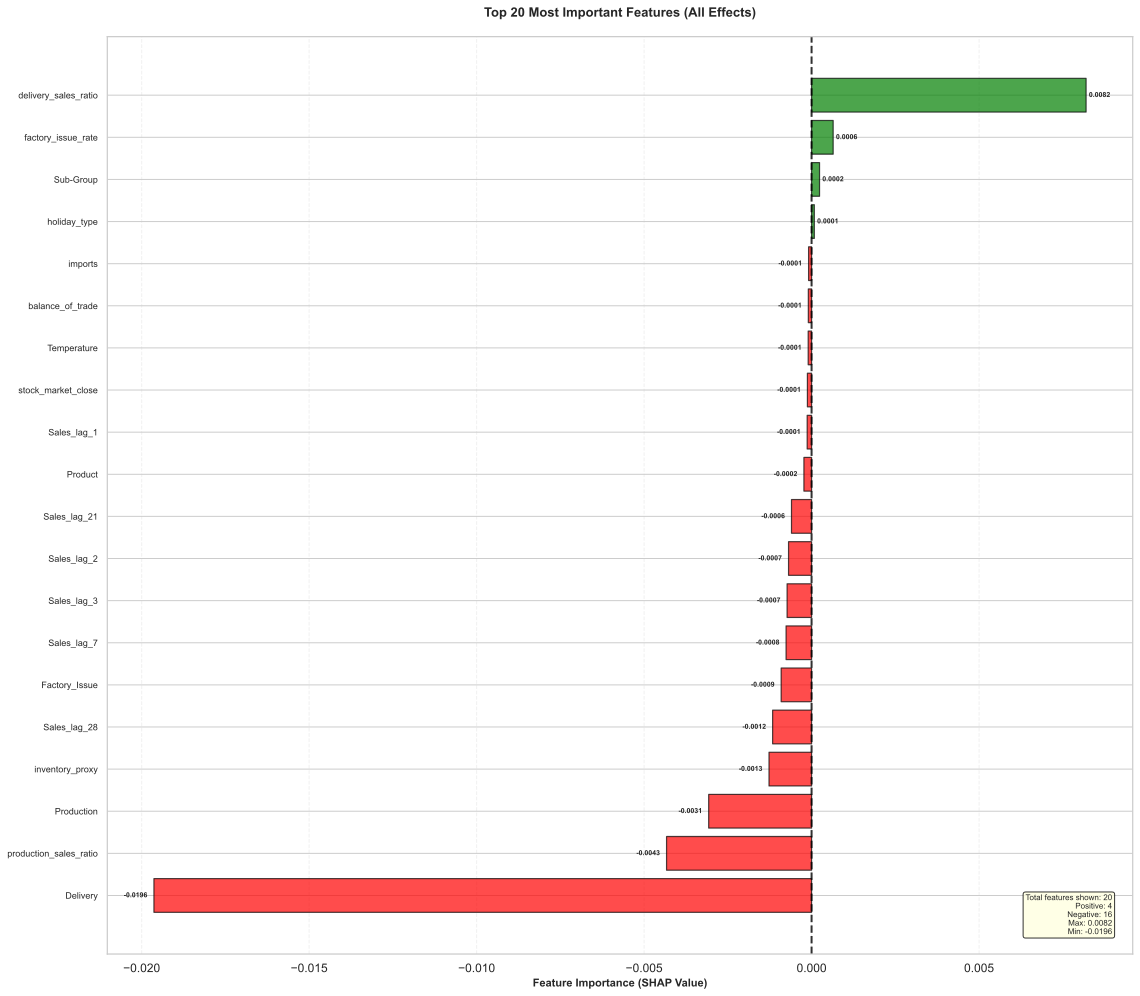

In [3]:
if os.path.exists(feature_impoprtance):
    display(SVG(filename=feature_impoprtance))
else:
    visualize_important_features(sub_causal_graph_importance_df, top_n=20, effect_type='both', figsize=(16, 14), fontsize=9)

<br> <br>

### Visualize sub causal graph

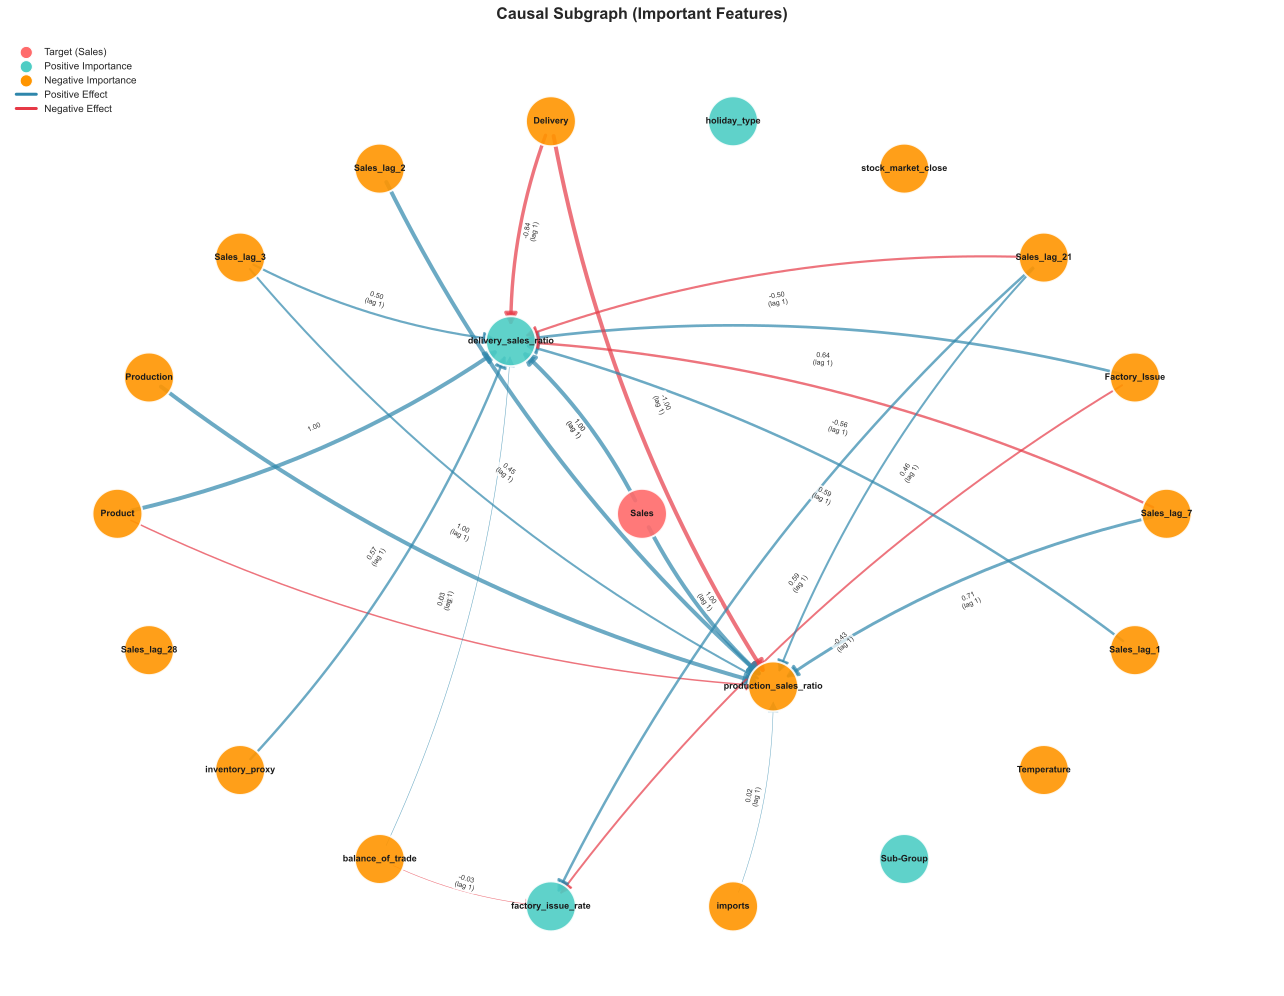

In [4]:
if os.path.exists(sub_causal_graph_svg):
    display(SVG(filename=sub_causal_graph_svg))
else:
    print(f"File not found: {sub_causal_graph_svg}")

<br> <br>

#### Macroeconomic features and their relationship existed in the sub causal graph

In [5]:
def filter_sub_causal_graph_by_features(clean_sub_causal_graph, enriched_kg_df):
    feature_set = set(enriched_kg_df["feature"].dropna())
    mask = (clean_sub_causal_graph["source"].isin(feature_set) | clean_sub_causal_graph["target"].isin(feature_set))
    return clean_sub_causal_graph.loc[mask].reset_index(drop=True)


# Example usage in your notebook:
filtered_sub_causal_graph_df = filter_sub_causal_graph_by_features(
    sub_causal_graph_csv.drop(columns=["Unnamed: 0"]),
    enriched_kg
)

filtered_sub_causal_graph_df

,source,target,weight
0,balance_of_trade,delivery_sales_ratio,0.033258
1,balance_of_trade,factory_issue_rate,-0.032606
2,imports,production_sales_ratio,0.018085


## Visualize the event graph

In [6]:
# ── Example usage ────────────────────────────────────────────────────────────
# Available themes :  "light"  |  "dark"  |  "pastel"  |  "highcontrast"
# Edge label styles:  "text"   |  "rectangle"  |  "roundrect"  |  "ellipse"  |  "circle"  |  "diamond"

visualize_knowledge_graph(
    df=enriched_kg,
    output_file=f"../kg_visualization/refined_triplet_kg_{date}_{time}_{row_number}.html",
    theme="highcontrast",                 # white background, readable colours
    node_size=25,                  # uniform node radius (px)
    node_font_size=14,             # node label font size (px)
    edge_font_size=12,             # edge label font size (px)
    edge_label_style= "roundrect"  #"text",    # plain text (no shape behind label)
)

Parsed 80 triplets from 80 rows
Interactive graph saved to: ../kg_visualization/refined_triplet_kg_20260402_121459_548.html
  Theme: highcontrast  |  Nodes: 76  |  Edges: 73
  Node size: 25  |  Node font: 14px  |  Edge font: 12px
  Edge label style: roundrect  |  Label padding: 5px
  Categories: Currency Movement, Global Shock, Government Policy, Industry Activity, Infrastructure, Market Dynamics, Monetary Policy, Trade Policy


'../kg_visualization/refined_triplet_kg_20260402_121459_548.html'

<br> <br>

### Query the Event graph

#### The complete graph

In [7]:
cols = ["url","title", "date", "feature", "refined_triplet", "attribute"]

# enriched_kg.assign(date=pd.to_datetime(enriched_kg["date"], errors="coerce"))[cols].sort_values("date", ascending=True).reset_index(drop=True)

enriched_kg[cols]


,url,title,date,feature,refined_triplet,attribute
0,https://www.aninews.in/news/world/asia/banglad...,Bangladesh may overtake China to be EU's bigge...,2023-01-24,imports,(Work Orders Shift to Bangladesh) ── decrease ...,"""Work Orders Shift: Market Dynamics"""
1,https://asianews.network/overcoming-looming-ec...,Overcoming looming economic challenges in 2023,2023-01-10,imports,(High Import Growth) ── increase ──> (imports),"""High Import Growth: Market Dynamics"""
2,https://www.bssnews.net/district/116749,Essential Commodities now available at stable ...,2023-03-21,imports,(Government boosts consumer imports) ── increa...,"""Government boosts consumer imports: Governmen..."
3,https://www.bssnews.net/business/120673,Businessmen will be happy seeing next budget: ...,2023-04-13,imports,(AIT Reduction at Import Stage) ── decrease ──...,"""AIT Reduction at Import Stage: Government Pol..."
4,https://www.irishsun.com/news/273832902/bangla...,Bangladesh government should think twice befor...,2023-05-16,imports,(Yuan Payments in Bangladesh) ── increase ──> ...,"""Yuan Payments: Currency Movement"""
5,https://hr.asia/media-outreach/dhl-global-forw...,DHL Global Forwarding expands its dedicated Co...,2023-05-02,imports,(Port Expansion Speeding Shipping) ── increase...,"""Port Expansion: Infrastructure"""
6,https://www.bssnews.net/district/116749,Essential Commodities now available at stable ...,2023-03-21,imports,(Huge Imports) ── increase ──> (imports),"""Huge Imports: Market Dynamics"""
7,https://www.bssnews.net/district/116749,Essential Commodities now available at stable ...,2023-03-21,imports,(Huge Imports) ── increase ──> (imports),"""Huge Imports: Trade Policy"""
8,https://www.hellenicshippingnews.com/commodity...,Commodity Tracker: 5 charts to watch this week,2023-06-20,imports,(Bangladesh's SPM facility) ── increase ──> (i...,"""SPM facility: Infrastructure"""
9,https://www.msn.com/en-xl/asia/bangladesh/doll...,Dollar crisis casts a shadow over operation of...,2023-02-17,imports,(Dollar Crisis at Rampal Plant) ── decrease ──...,"""Dollar Crisis: Currency Movement"""


In [9]:
enriched_kg.drop(columns=["Unnamed: 0"])

,json_file,title,date,url,source,feature,edge_label,event_summary,triplet_semantic,quote_similarity,quote_best_match,judge_verdict,judge_reasoning,triplet_date,subject,predicate,object,parse_ok,new_subject,new_predicate,new_object,new_triplet,normalized_direction,normalized_triplet,refined_subject,refined_triplet,attribute
0,llm_response_0015_Asian_News_International_ANI...,Bangladesh may overtake China to be EU's bigge...,2023-01-24,https://www.aninews.in/news/world/asia/banglad...,Asian News International (ANI),imports,diverts work orders,Work orders shift to Bangladesh,"2023-01-24, The volume of goods brought in, dr...",0.985,This is resulting in work orders being shifted...,CONFIRMED,The quoted sentence appears verbatim in the ar...,2023-01-24,"The volume of goods brought in, driven by Lett...",diverts work orders,Work orders shift to Bangladesh,True,Work Orders Shift,diverts work orders,Bangladesh,(Work Orders Shift) ── diverts work orders ──>...,decrease,(Work Orders Shift) ── decrease ──> (imports),Work Orders Shift to Bangladesh,(Work Orders Shift to Bangladesh) ── decrease ...,"""Work Orders Shift: Market Dynamics"""
1,llm_response_0034_ANN_20230110.json,Overcoming looming economic challenges in 2023,2023-01-10,https://asianews.network/overcoming-looming-ec...,ANN,imports,worsens import balance,Import growth raises deficit,"2023-01-10, The volume of goods brought in, dr...",1.000,High import growth and low remittance growth h...,CONFIRMED,"The quote appears verbatim in the article: ""Hi...",2023-01-10,"The volume of goods brought in, driven by Lett...",worsens import balance,Import growth raises deficit,True,High Import Growth,worsens import balance,Current Account Deficit,(High Import Growth) ── worsens import balance...,increase,(High Import Growth) ── increase ──> (imports),High Import Growth,(High Import Growth) ── increase ──> (imports),"""High Import Growth: Market Dynamics"""
2,llm_response_0042_Bangladesh_Sangbad_Sangstha_...,Essential Commodities now available at stable ...,2023-03-21,https://www.bssnews.net/district/116749,Bangladesh Sangbad Sangstha (BSS),imports,increases imports,Government boosts consumer imports,"2023-03-21, The volume of goods brought in, dr...",1.000,The Government has taken necessary steps for i...,CONFIRMED,The quoted sentence appears in the article alm...,2023-03-21,"The volume of goods brought in, driven by Lett...",increases imports,Government boosts consumer imports,True,Government,increases imports,Consumer Goods,(Government) ── increases imports ──> (Consume...,increase,(Government) ── increase ──> (imports),Government boosts consumer imports,(Government boosts consumer imports) ── increa...,"""Government boosts consumer imports: Governmen..."
3,llm_response_0053_Bangladesh_Sangbad_Sangstha_...,Businessmen will be happy seeing next budget: ...,2023-04-13,https://www.bssnews.net/business/120673,Bangladesh Sangbad Sangstha (BSS),imports,reduces import cost,AIT cuts at import stage,"2023-04-13, The volume of goods brought in, dr...",0.997,reducing Advance Income Tax (AIT) in phases at...,CONFIRMED,"The article explicitly says FBCCI proposed ""re...",2023-04-13,"The volume of goods brought in, driven by Lett...",reduces import cost,AIT cuts at import stage,True,AIT Cuts,reduces import cost,Cost in Industrial Production,(AIT Cuts) ── reduces import cost ──> (Cost in...,decrease,(AIT Cuts) ── decrease ──> (imports),AIT Reduction at Import Stage,(AIT Reduction at Import Stage) ── decrease ──...,"""AIT Reduction at Import Stage: Government Pol..."
4,llm_response_0057_Irish_Sun_20230516.json,Bangladesh government should think twice befor...,2023-05-16,https://www.irishsun.com/news/273832902/bangla...,Irish Sun,imports,reduces import payment friction,Yuan payments aid imports,"2023-05-16, The volume of goods brought in, dr...",0.988,Bangladesh can lessen its reliance on the doll...,CONFIRMED,"The article explicitly says, 'According to exp...",2023-05-16,"The volume of goods brought in, d

<br> <br> <br>
 
#### Filtering the graph

In [10]:
mac_evgr_feature = "imports"  # imports, balance_of_trade, stock_market_close  # macroeconimic feature in event graph

balance_of_trade_rows = enriched_kg.loc[enriched_kg["feature"] == mac_evgr_feature].reset_index(drop=True)
balance_of_trade_rows[cols]

,url,title,date,feature,refined_triplet,attribute
0,https://www.aninews.in/news/world/asia/banglad...,Bangladesh may overtake China to be EU's bigge...,2023-01-24,imports,(Work Orders Shift to Bangladesh) ── decrease ...,"""Work Orders Shift: Market Dynamics"""
1,https://asianews.network/overcoming-looming-ec...,Overcoming looming economic challenges in 2023,2023-01-10,imports,(High Import Growth) ── increase ──> (imports),"""High Import Growth: Market Dynamics"""
2,https://www.bssnews.net/district/116749,Essential Commodities now available at stable ...,2023-03-21,imports,(Government boosts consumer imports) ── increa...,"""Government boosts consumer imports: Governmen..."
3,https://www.bssnews.net/business/120673,Businessmen will be happy seeing next budget: ...,2023-04-13,imports,(AIT Reduction at Import Stage) ── decrease ──...,"""AIT Reduction at Import Stage: Government Pol..."
4,https://www.irishsun.com/news/273832902/bangla...,Bangladesh government should think twice befor...,2023-05-16,imports,(Yuan Payments in Bangladesh) ── increase ──> ...,"""Yuan Payments: Currency Movement"""
5,https://hr.asia/media-outreach/dhl-global-forw...,DHL Global Forwarding expands its dedicated Co...,2023-05-02,imports,(Port Expansion Speeding Shipping) ── increase...,"""Port Expansion: Infrastructure"""
6,https://www.bssnews.net/district/116749,Essential Commodities now available at stable ...,2023-03-21,imports,(Huge Imports) ── increase ──> (imports),"""Huge Imports: Market Dynamics"""
7,https://www.bssnews.net/district/116749,Essential Commodities now available at stable ...,2023-03-21,imports,(Huge Imports) ── increase ──> (imports),"""Huge Imports: Trade Policy"""
8,https://www.hellenicshippingnews.com/commodity...,Commodity Tracker: 5 charts to watch this week,2023-06-20,imports,(Bangladesh's SPM facility) ── increase ──> (i...,"""SPM facility: Infrastructure"""
9,https://www.msn.com/en-xl/asia/bangladesh/doll...,Dollar crisis casts a shadow over operation of...,2023-02-17,imports,(Dollar Crisis at Rampal Plant) ── decrease ──...,"""Dollar Crisis: Currency Movement"""


<br> <br>

## Combine the Event Graph and Causal Graph

In [11]:
unified_graph_df = build_unified_graph(filtered_sub_causal_graph_df, enriched_kg)
unified_graph_df

,source,relation,target,edge_type,weight,date,title,attribute
0,Yuan Use for Imports,improve,balance_of_trade,event,NaN,2023-05-16,Bangladesh government should think twice befor...,"""Yuan Use for Imports: Currency Movement"""
1,balance_of_trade,has_attribute,Currency Movement,attribute,NaN,2023-05-16,Bangladesh government should think twice befor...,"""Yuan Use for Imports: Currency Movement"""
2,Yuan Use in Trade,deteriorate,balance_of_trade,event,NaN,2023-05-16,Bangladesh government should think twice befor...,"""Yuan Use in Trade: Currency Movement"""
3,balance_of_trade,has_attribute,Currency Movement,attribute,NaN,2023-05-16,Bangladesh government should think twice befor...,"""Yuan Use in Trade: Currency Movement"""
4,Russia-Ukraine War Impact,deteriorate,balance_of_trade,event,NaN,2023-06-01,Govt aims to sustain economic recovery: Kamal ...,"""Russia-Ukraine War Impact: Global Shock"""
...,...,...,...,...,...,...,...,...
163,Sugar Import Costs,decrease,imports,event,NaN,2023-02-28,Bangladesh Withdraws Duty On Sugar Import To S...,"""Sugar Import Costs: Market Dynamics"""
164,imports,has_attribute,Market Dynamics,attribute,NaN,2023-02-28,Bangladesh Withdraws Duty On Sugar Import To S...,"""Sugar Import Costs: Market Dynamics"""
165,Shortage of Greenbacks,decrease,imports,event,NaN,2023-01-20,"Money or no money, crisis persists","""Shortage of Greenbacks: Currency Movement"""
166,imports,has_attribute,Currency Movement,attribute,NaN,2023-01-20,"Money or no money, crisis persists","""Shortage of Greenbacks: Currency Movement"""


In [12]:
from datetime import datetime
# display_mode: "all" | "event" | "causal"
# show_edge_labels: True | False

now = datetime.now()
current_date = now.strftime("%Y%m%d")   
current_time = now.strftime("%H%M%S")   

display_mode = "all"

match display_mode:
    case "all":
        output_file = f"../unified_causal_event_graph/unified_causal_event_graph_{current_date}_{current_time}_{row_number}_all.html"
    case "event":
        output_file = f"../unified_causal_event_graph/unified_causal_event_graph_{current_date}_{current_time}_{row_number}_event.html"
    case "causal":
        output_file = f"../unified_causal_event_graph/unified_causal_event_graph_{current_date}_{current_time}_{row_number}_causal.html"
    case _:
        output_file = f"../unified_causal_event_graph/unified_causal_event_graph_{current_date}_{current_time}_{row_number}_all.html"


visualize_unified_graph(
    unified_df=unified_graph_df,
    output_file= output_file,
    display_mode=display_mode,
    show_edge_labels=True, 
    theme="pastel",
    node_size=25,
    node_font_size=14,
    edge_font_size=12,
    edge_label_style="roundrect",
)

Unified causal+event graph saved to: ../unified_causal_event_graph/unified_causal_event_graph_20260409_144140_548_all.html
  Display mode: all  |  Theme: pastel  |  Nodes: 84  |  Edges: 85
  Event edges: 78  |  Causal edges: 3  |  Attribute edges: 87
  Node size: 25  |  Node font: 14px  |  Edge font: 12px
  Edge label style: roundrect  |  Label padding: 5px
  Categories: Causal Feature, Currency Movement, Global Shock, Government Policy, Industry Activity, Infrastructure, Market Dynamics, Monetary Policy, Trade Policy


'../unified_causal_event_graph/unified_causal_event_graph_20260409_144140_548_all.html'

<br> <br> <br>

## Check the past event

<br> <br> 

Find the same row that is in X_test. We need to this in order to have access to the date

In [13]:
display(Markdown("### Random Row\n\n"))
display(row)


row_features = row.drop(columns=["Unnamed: 0", "actual", "predicted", "residual"], errors="ignore")
common_cols = [c for c in X_test.columns if c in row_features.columns]

candidate = row_features.iloc[0][common_cols]

numeric_cols = X_test[common_cols].select_dtypes(include=[np.number]).columns
mask = pd.Series(True, index=X_test.index)

if len(numeric_cols) > 0:
    mask &= np.isclose(
        X_test[numeric_cols].to_numpy(),
        candidate[numeric_cols].to_numpy(),
        rtol=1e-6,
        atol=1e-8
    ).all(axis=1)

for col in [c for c in common_cols if c not in numeric_cols]:
    mask &= X_test[col].eq(candidate[col])

matched_row = X_test.loc[mask]

display(Markdown("### X_test Row\n\n"))
display(matched_row)
display(Markdown(f"\n\n#### Random row date of occurence: {matched_row['Date'].iloc[0]}"))


### Random Row



,Unnamed: 0,Product,Production,Factory_Issue,Delivery,Group,Sub-Group,holiday_type,holiday_name,Rainfall,Sunshine,Humidity,Temperature,category,scope_or_location,typical_rain_mm,Sales_lag_1,Sales_lag_2,Sales_lag_3,Sales_lag_7,Sales_lag_14,Sales_lag_21,Sales_lag_28,production_sales_ratio,delivery_sales_ratio,factory_issue_rate,inventory_proxy,interest_rate_value,stock_market_close,inflation_rate,balance_of_trade,exports,imports,currency_log_return,currency_momentum_5d,actual,predicted,residual
0,Sample_1 (idx=548),18,0.025982,0.035683,0.004752,3,12,2,13,0.0,0.52381,0.587302,0.884058,4,6,0.0,0.007829,0.005675,0.006735,0.001538,0.018016,0.0,0.007521,2.36715,0.425121,1.428571,0.617673,0.0,0.993405,0.817518,0.0,1.0,1.0,0.569523,0.67644,0.007077,0.005286,0.001791


### X_test Row



,Date,Product,Production,Factory_Issue,Delivery,Group,Sub-Group,holiday_type,holiday_name,Rainfall,Sunshine,Humidity,Temperature,category,scope_or_location,typical_rain_mm,Sales_lag_1,Sales_lag_2,Sales_lag_3,Sales_lag_7,Sales_lag_14,Sales_lag_21,Sales_lag_28,production_sales_ratio,delivery_sales_ratio,factory_issue_rate,inventory_proxy,interest_rate_value,stock_market_close,inflation_rate,balance_of_trade,exports,imports,currency_log_return,currency_momentum_5d
4177,2023-07-19,18,0.025982,0.035683,0.004752,3,12,2,13,0.0,0.52381,0.587302,0.884058,4,6,0.0,0.007829,0.005675,0.006735,0.001538,0.018016,0.0,0.007521,2.36715,0.425121,1.428571,0.617673,0.0,0.993405,0.817518,0.0,1.0,1.0,0.569523,0.67644




#### Random row date of occurence: 2023-07-19

In [14]:
unified_graph_df

,source,relation,target,edge_type,weight,date,title,attribute
0,Yuan Use for Imports,improve,balance_of_trade,event,NaN,2023-05-16,Bangladesh government should think twice befor...,"""Yuan Use for Imports: Currency Movement"""
1,balance_of_trade,has_attribute,Currency Movement,attribute,NaN,2023-05-16,Bangladesh government should think twice befor...,"""Yuan Use for Imports: Currency Movement"""
2,Yuan Use in Trade,deteriorate,balance_of_trade,event,NaN,2023-05-16,Bangladesh government should think twice befor...,"""Yuan Use in Trade: Currency Movement"""
3,balance_of_trade,has_attribute,Currency Movement,attribute,NaN,2023-05-16,Bangladesh government should think twice befor...,"""Yuan Use in Trade: Currency Movement"""
4,Russia-Ukraine War Impact,deteriorate,balance_of_trade,event,NaN,2023-06-01,Govt aims to sustain economic recovery: Kamal ...,"""Russia-Ukraine War Impact: Global Shock"""
...,...,...,...,...,...,...,...,...
163,Sugar Import Costs,decrease,imports,event,NaN,2023-02-28,Bangladesh Withdraws Duty On Sugar Import To S...,"""Sugar Import Costs: Market Dynamics"""
164,imports,has_attribute,Market Dynamics,attribute,NaN,2023-02-28,Bangladesh Withdraws Duty On Sugar Import To S...,"""Sugar Import Costs: Market Dynamics"""
165,Shortage of Greenbacks,decrease,imports,event,NaN,2023-01-20,"Money or no money, crisis persists","""Shortage of Greenbacks: Currency Movement"""
166,imports,has_attribute,Currency Movement,attribute,NaN,2023-01-20,"Money or no money, crisis persists","""Shortage of Greenbacks: Currency Movement"""


In [15]:
cols = ["url","title", "date", "feature", "refined_triplet", "attribute"]

enriched_kg[cols]

,url,title,date,feature,refined_triplet,attribute
0,https://www.aninews.in/news/world/asia/banglad...,Bangladesh may overtake China to be EU's bigge...,2023-01-24,imports,(Work Orders Shift to Bangladesh) ── decrease ...,"""Work Orders Shift: Market Dynamics"""
1,https://asianews.network/overcoming-looming-ec...,Overcoming looming economic challenges in 2023,2023-01-10,imports,(High Import Growth) ── increase ──> (imports),"""High Import Growth: Market Dynamics"""
2,https://www.bssnews.net/district/116749,Essential Commodities now available at stable ...,2023-03-21,imports,(Government boosts consumer imports) ── increa...,"""Government boosts consumer imports: Governmen..."
3,https://www.bssnews.net/business/120673,Businessmen will be happy seeing next budget: ...,2023-04-13,imports,(AIT Reduction at Import Stage) ── decrease ──...,"""AIT Reduction at Import Stage: Government Pol..."
4,https://www.irishsun.com/news/273832902/bangla...,Bangladesh government should think twice befor...,2023-05-16,imports,(Yuan Payments in Bangladesh) ── increase ──> ...,"""Yuan Payments: Currency Movement"""
5,https://hr.asia/media-outreach/dhl-global-forw...,DHL Global Forwarding expands its dedicated Co...,2023-05-02,imports,(Port Expansion Speeding Shipping) ── increase...,"""Port Expansion: Infrastructure"""
6,https://www.bssnews.net/district/116749,Essential Commodities now available at stable ...,2023-03-21,imports,(Huge Imports) ── increase ──> (imports),"""Huge Imports: Market Dynamics"""
7,https://www.bssnews.net/district/116749,Essential Commodities now available at stable ...,2023-03-21,imports,(Huge Imports) ── increase ──> (imports),"""Huge Imports: Trade Policy"""
8,https://www.hellenicshippingnews.com/commodity...,Commodity Tracker: 5 charts to watch this week,2023-06-20,imports,(Bangladesh's SPM facility) ── increase ──> (i...,"""SPM facility: Infrastructure"""
9,https://www.msn.com/en-xl/asia/bangladesh/doll...,Dollar crisis casts a shadow over operation of...,2023-02-17,imports,(Dollar Crisis at Rampal Plant) ── decrease ──...,"""Dollar Crisis: Currency Movement"""


<br> <br> <br>

## Static Visualization

In [16]:
days_back = 1000

# Create output directory if it doesn't exist
output_dir = f"../event_time_window/events_{row_number}_{days_back}d"
os.makedirs(output_dir, exist_ok=True)

path, df_event_in_time = visualize_events_in_time_window(
    unified_df=unified_graph_df,
    reference_date=matched_row["Date"],   # 2023-07-19
    days_back=days_back,                  # show events from 40 days before
    output_file=f"../event_time_window/events_{row_number}_{days_back}d/events_{row_number}_{days_back}d.html",
    theme="pastel",
    edge_label_style="roundrect",
)

df_event_in_time.to_csv(f"../event_time_window/events_{row_number}_{days_back}d/events_{row_number}_{days_back}d.csv")

Event time-window graph saved to: ../event_time_window/events_548_1000d/events_548_1000d.html
  Reference date: 2023-07-19  |  Window: 1000 days back  (from 2020-10-22)
  Event edges: 71  |  Attribute edges: 11  |  Nodes: 81
  Theme: pastel


In [17]:
# days_back and row_number should be existed in in "event_time_window" folder
days_back = 45
row_number = 548

df_event_in_time = pd.read_csv(f"../event_time_window/events_{row_number}_{days_back}d/events_{row_number}_{days_back}d.csv")
df_event_in_time.drop(columns=["Unnamed: 0"])

,source,relation,target,edge_type,weight,date,title,attribute,days_before
0,imports,has_attribute,Government Policy,attribute,NaN,2023-07-03,1.14 lakh kilograms of green chilli imported o...,"""Government's Permission: Government Policy"", ...",16
1,imports,has_attribute,Trade Policy,attribute,NaN,2023-07-03,1.14 lakh kilograms of green chilli imported o...,"""Government's Permission: Government Policy"", ...",16
2,"Government's Permission to Import 36,830 Tons",increase,imports,event,NaN,2023-07-03,1.14 lakh kilograms of green chilli imported o...,"""Government's Permission: Government Policy"", ...",16
3,Government Permission to Import Chilli,increase,imports,event,NaN,2023-07-02,"Govt allows import of 36,830 tons green chilli...","""Government Permission: Government Policy"", ""I...",17
4,imports,has_attribute,Government Policy,attribute,NaN,2023-07-02,"Govt allows import of 36,830 tons green chilli...","""Government Permission: Government Policy"", ""I...",17
5,imports,has_attribute,Trade Policy,attribute,NaN,2023-07-02,"Govt allows import of 36,830 tons green chilli...","""Government Permission: Government Policy"", ""I...",17
6,imports,has_attribute,Infrastructure,attribute,NaN,2023-06-26,Inflation fight gets tougher: Bank for Interna...,"""Supply Chain Easing: Infrastructure""",23
7,Supply Chain Easing,increase,imports,event,NaN,2023-06-26,Inflation fight gets tougher: Bank for Interna...,"""Supply Chain Easing: Infrastructure""",23
8,Bangladesh's SPM facility,increase,imports,event,NaN,2023-06-20,Commodity Tracker: 5 charts to watch this week,"""SPM facility: Infrastructure""",29
9,imports,has_attribute,Infrastructure,attribute,NaN,2023-06-20,Commodity Tracker: 5 charts to watch this week,"""SPM facility: Infrastructure""",29


<br> <br> <br>

### Dynamic Visualization

In [18]:
visualize_events_in_time_window_dynamic(
    unified_df=unified_graph_df,
    reference_date=matched_row["Date"],
    days_back=35,
    output_file=f"../event_time_window_dynamic/events_{row_number}_dynamic.html",
    theme="pastel",
    edge_label_style="roundrect",
)

Dynamic event time-window graph saved to: ../event_time_window_dynamic/events_548_dynamic.html
  Reference date: 2023-07-19  |  Default window: 35 days
  Theme: pastel


'../event_time_window_dynamic/events_548_dynamic.html'

In [19]:
enriched_kg[cols]

,url,title,date,feature,refined_triplet,attribute
0,https://www.aninews.in/news/world/asia/banglad...,Bangladesh may overtake China to be EU's bigge...,2023-01-24,imports,(Work Orders Shift to Bangladesh) ── decrease ...,"""Work Orders Shift: Market Dynamics"""
1,https://asianews.network/overcoming-looming-ec...,Overcoming looming economic challenges in 2023,2023-01-10,imports,(High Import Growth) ── increase ──> (imports),"""High Import Growth: Market Dynamics"""
2,https://www.bssnews.net/district/116749,Essential Commodities now available at stable ...,2023-03-21,imports,(Government boosts consumer imports) ── increa...,"""Government boosts consumer imports: Governmen..."
3,https://www.bssnews.net/business/120673,Businessmen will be happy seeing next budget: ...,2023-04-13,imports,(AIT Reduction at Import Stage) ── decrease ──...,"""AIT Reduction at Import Stage: Government Pol..."
4,https://www.irishsun.com/news/273832902/bangla...,Bangladesh government should think twice befor...,2023-05-16,imports,(Yuan Payments in Bangladesh) ── increase ──> ...,"""Yuan Payments: Currency Movement"""
5,https://hr.asia/media-outreach/dhl-global-forw...,DHL Global Forwarding expands its dedicated Co...,2023-05-02,imports,(Port Expansion Speeding Shipping) ── increase...,"""Port Expansion: Infrastructure"""
6,https://www.bssnews.net/district/116749,Essential Commodities now available at stable ...,2023-03-21,imports,(Huge Imports) ── increase ──> (imports),"""Huge Imports: Market Dynamics"""
7,https://www.bssnews.net/district/116749,Essential Commodities now available at stable ...,2023-03-21,imports,(Huge Imports) ── increase ──> (imports),"""Huge Imports: Trade Policy"""
8,https://www.hellenicshippingnews.com/commodity...,Commodity Tracker: 5 charts to watch this week,2023-06-20,imports,(Bangladesh's SPM facility) ── increase ──> (i...,"""SPM facility: Infrastructure"""
9,https://www.msn.com/en-xl/asia/bangladesh/doll...,Dollar crisis casts a shadow over operation of...,2023-02-17,imports,(Dollar Crisis at Rampal Plant) ── decrease ──...,"""Dollar Crisis: Currency Movement"""


<br> <br> <br>


## Generate Explanation 


Generate Explanation Based on Merged Graph which is **Enriched_kg** dataframe

In [20]:
unified_graph_df

,source,relation,target,edge_type,weight,date,title,attribute
0,Yuan Use for Imports,improve,balance_of_trade,event,NaN,2023-05-16,Bangladesh government should think twice befor...,"""Yuan Use for Imports: Currency Movement"""
1,balance_of_trade,has_attribute,Currency Movement,attribute,NaN,2023-05-16,Bangladesh government should think twice befor...,"""Yuan Use for Imports: Currency Movement"""
2,Yuan Use in Trade,deteriorate,balance_of_trade,event,NaN,2023-05-16,Bangladesh government should think twice befor...,"""Yuan Use in Trade: Currency Movement"""
3,balance_of_trade,has_attribute,Currency Movement,attribute,NaN,2023-05-16,Bangladesh government should think twice befor...,"""Yuan Use in Trade: Currency Movement"""
4,Russia-Ukraine War Impact,deteriorate,balance_of_trade,event,NaN,2023-06-01,Govt aims to sustain economic recovery: Kamal ...,"""Russia-Ukraine War Impact: Global Shock"""
...,...,...,...,...,...,...,...,...
163,Sugar Import Costs,decrease,imports,event,NaN,2023-02-28,Bangladesh Withdraws Duty On Sugar Import To S...,"""Sugar Import Costs: Market Dynamics"""
164,imports,has_attribute,Market Dynamics,attribute,NaN,2023-02-28,Bangladesh Withdraws Duty On Sugar Import To S...,"""Sugar Import Costs: Market Dynamics"""
165,Shortage of Greenbacks,decrease,imports,event,NaN,2023-01-20,"Money or no money, crisis persists","""Shortage of Greenbacks: Currency Movement"""
166,imports,has_attribute,Currency Movement,attribute,NaN,2023-01-20,"Money or no money, crisis persists","""Shortage of Greenbacks: Currency Movement"""


In [21]:
row_number = 548
days = 45

# Causal graph for macroeconomic features
filterd_sub_causal_graph_for_explanation = filtered_sub_causal_graph_df[["source", "target", "weight"]].copy()
filterd_sub_causal_graph_for_explanation["sign"] = np.where(np.sign(filterd_sub_causal_graph_for_explanation["weight"]) == 1, "positive", "negative")


# Event graph
df = pd.read_csv(f"../event_time_window/events_{row_number}_{days_back}d/events_{row_number}_{days_back}d.csv")
edge_type = ["event"] # "event", "attribute", "causal"
unified_graph_no_attribute_df = df.loc[df["edge_type"].isin(edge_type)].reset_index(drop=True)
event_triplets = unified_graph_no_attribute_df[["source", "relation", "target"]]

display(filterd_sub_causal_graph_for_explanation)
display(event_triplets)

,source,target,weight,sign
0,balance_of_trade,delivery_sales_ratio,0.033258,positive
1,balance_of_trade,factory_issue_rate,-0.032606,negative
2,imports,production_sales_ratio,0.018085,positive


,source,relation,target
0,"Government's Permission to Import 36,830 Tons",increase,imports
1,Government Permission to Import Chilli,increase,imports
2,Supply Chain Easing,increase,imports
3,Bangladesh's SPM facility,increase,imports
4,Foreign Exchange Reserves Decline,decrease,imports
5,Import Disruption,decrease,imports


In [22]:
ref_date = pd.to_datetime(matched_row["Date"].iloc[0], errors="coerce")
max_graph_date = pd.to_datetime(unified_graph_no_attribute_df["date"], errors="coerce").max()
min_graph_date = pd.to_datetime(unified_graph_no_attribute_df["date"], errors="coerce").min()

if pd.isna(ref_date) or pd.isna(max_graph_date):
    print("Could not compute date difference (invalid/missing date).")
else:
    diff_days_max = (ref_date - max_graph_date).days
    diff_days_min = (ref_date - min_graph_date).days
    print(f"Random row date: {ref_date.date()}")
    # print(f"max graph date : {max_graph_date.date()}")
    print(f"Min graph date : {min_graph_date.date()}")
    # print(f"max difference (days): {diff_days_max}")
    print(f"\nDifference in days: {diff_days_min} days")    

Random row date: 2023-07-19
Min graph date : 2023-06-04

Difference in days: 45 days


In [23]:
unified_graph_no_attribute_df_sort_by_date = (
    unified_graph_no_attribute_df
    .drop(columns=["Unnamed: 0"], errors="ignore")
    .assign(date=pd.to_datetime(unified_graph_no_attribute_df["date"], errors="coerce"))
    .sort_values("date", ascending=True)
    .reset_index(drop=True)
)

unified_graph_no_attribute_df_sort_by_date

,source,relation,target,edge_type,weight,date,title,attribute,days_before
0,Import Disruption,decrease,imports,event,NaN,2023-06-04,"Global prices fall, no impact on local market...","""Import Disruption: Global Shock""",45
1,Foreign Exchange Reserves Decline,decrease,imports,event,NaN,2023-06-08,Bangladesh suffers long power cuts amid worst ...,"""Foreign Exchange Reserves Decline: Monetary P...",41
2,Bangladesh's SPM facility,increase,imports,event,NaN,2023-06-20,Commodity Tracker: 5 charts to watch this week,"""SPM facility: Infrastructure""",29
3,Supply Chain Easing,increase,imports,event,NaN,2023-06-26,Inflation fight gets tougher: Bank for Interna...,"""Supply Chain Easing: Infrastructure""",23
4,Government Permission to Import Chilli,increase,imports,event,NaN,2023-07-02,"Govt allows import of 36,830 tons green chilli...","""Government Permission: Government Policy"", ""I...",17
5,"Government's Permission to Import 36,830 Tons",increase,imports,event,NaN,2023-07-03,1.14 lakh kilograms of green chilli imported o...,"""Government's Permission: Government Policy"", ...",16


<br> <br> <br>
 

Generate the Explanation

In [27]:
# Generate explanation
explanation = generate_explanation(    
    event_triplets_df=event_triplets,
    causal_relations_df=filterd_sub_causal_graph_for_explanation,
    row_number=row_number,
    openrouter_api_key=openrouter_api_key,
    max_words = 100, #"no_limit",
    llm_name = "openai/gpt-5.4"
)

In [28]:
display(Markdown(explanation))

Recent policy moves support higher imports. The government approved 36,830 tons and chilli imports, supply chains are easing, and Bangladesh’s SPM facility also helps inflows. But lower foreign exchange reserves and possible import disruption can still restrict supply.

Why it matters: more imports can lift the production-to-sales ratio, meaning better product availability and smoother replenishment. A stronger trade balance usually improves delivery-to-sales performance and lowers factory issue rates.

Watch-outs: currency and reserve pressure may delay imports. Opportunities: secure import orders early, diversify suppliers, and use improving import conditions to rebuild critical inventory.

<br> <br>

#### Read the saved explanation

In [29]:
def display_explanation_from_json(json_file_path: str) -> str:
    """
    Read a JSON file and display only the explanation section.
    Returns the explanation text.
    """
    with open(json_file_path, "r", encoding="utf-8") as f:
        payload = json.load(f)

    explanation = payload.get("explanation")
    if not explanation:
        raise ValueError("No 'explanation' field found in the JSON file.")

    display(Markdown("### Explanation\n\n" + explanation))
    return explanation

In [ ]:
json_path = "../llm_response/response_548_2026-04-09_14-43-19.json"

explanation_text = display_explanation_from_json(json_path)

### Explanation

Recent policy moves support higher imports. The government approved 36,830 tons and chilli imports, supply chains are easing, and Bangladesh’s SPM facility also helps inflows. But lower foreign exchange reserves and possible import disruption can still restrict supply.

Why it matters: more imports can lift the production-to-sales ratio, meaning better product availability and smoother replenishment. A stronger trade balance usually improves delivery-to-sales performance and lowers factory issue rates.

Watch-outs: currency and reserve pressure may delay imports. Opportunities: secure import orders early, diversify suppliers, and use improving import conditions to rebuild critical inventory.